In [1]:
import pandas as pd
import numpy as np
import json
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")

Libraries loaded.


In [2]:
# 1. Load the GeoJSON and inspect structure, types, and missingness yourself
gdf = gpd.read_file("business-licences.geojson")

# convert geo to plain dataframe
df = pd.DataFrame(gdf.drop(columns="geometry"))
df["lat"] = gdf.geometry.y
df["lon"] = gdf.geometry.x

print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")

Shape: (204107, 27)

Column types:
folderyear                                  object
licencersn                                  object
licencenumber                               object
licencerevisionnumber                       object
businessname                                object
businesstradename                           object
status                                      object
issueddate                     datetime64[ms, UTC]
expireddate                         datetime64[ms]
businesstype                                object
businesssubtype                             object
unit                                        object
unittype                                    object
house                                       object
street                                      object
city                                        object
province                                    object
country                                     object
postalcode                                  obj

In [3]:
# inspect structure types and missingness

missing_summary = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "percent_missing": (df.isna().mean() * 100).round(1),
}).sort_values("percent_missing", ascending=False)

print(f"missingness per column:\n{missing_summary.to_string()}")

df.head(3)

missingness per column:
                       n_missing  percent_missing
geom                      204107            100.0
businesssubtype           182589             89.5
unittype                  155457             76.2
unit                      155193             76.0
businesstradename         126800             62.1
lon                       101541             49.7
lat                       101541             49.7
geo_point_2d              101541             49.7
postalcode                 95141             46.6
house                      94403             46.3
street                     94386             46.2
feepaid                    75458             37.0
country                    44874             22.0
issueddate                 28811             14.1
expireddate                28787             14.1
businessname               13472              6.6
localarea                   2714              1.3
businesstype                   0              0.0
licencenumber             

,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,...,country,postalcode,localarea,numberofemployees,feepaid,extractdate,geom,geo_point_2d,lat,lon
0,24,4518841,24-138560,10,Nobl Collective Ltd,None,Issued,2023-12-28 21:34:28+00:00,2024-12-31,Consulting and Management Services,...,CA,None,Kitsilano,1.0,NaN,2026-07-01 02:32:17-07:00,None,None,NaN,NaN
1,24,4518843,24-138562,10,645064 BC Ltd,Trade Exchange Canada,Issued,2023-11-20 21:40:18+00:00,2024-12-31,Business Support Services,...,CA,None,Kitsilano,1.0,NaN,2026-07-01 02:32:17-07:00,None,None,NaN,NaN
2,24,4518844,24-138563,10,(Louise Turgeon),Turgeon Business Consulting,Issued,2023-11-21 22:30:07+00:00,2024-12-31,Consulting and Management Services,...,CA,None,Downtown,1.0,NaN,2026-07-01 02:32:17-07:00,None,None,NaN,NaN


2. Decide how to handle records with no geographic coordinates, and missing numberofemployees/feepaid — justify your choice
So as mentioned in the README that I dont need to hand-fix all messy fields, but only need those feed one of my features or a filter. 

Those I would leave alone are:
- unittype (76%), unit (76%), house (46%), street (46%). Cause I already have coordinates so anything related to street address is redundant. -> none of it feeds a feature.
- postalcode (46.6%). This could be helpful but 46.6% missing values is too much so instead of using this I can go with localarea (1.3%).
- busnesstradename (62%) and businessname (6.6%). No need cause they are just names not features
- province, country (22.0%). The README says just dont need to hand-fix these
- issueddate (14.1%), expireddate (14.1%). These are actually do important for a feature in the future but the missingness is low becomes relevant when I build that feature, so I handle it

So the col I actually investigate are the ones feeding a features or a filtures such as freepaid, numberofemplouees, coordinates. So the next thing I need to do is figure out why it's missing. 

feepaid missing rate by licence year (Issued only):
folderyear
24    0.840
25    0.007
26    0.006

share of rows with numberofemployees == 0 : 0.358
business types of the 0-employee rows:
businesstype
Long-term Rental                          44897
Short-term Rental Operator                13334
General Contractor                         2318
Health Care Professionals and Services     1527
Parking Area / Garage                      1197

rows with usable coordinates : 0.503


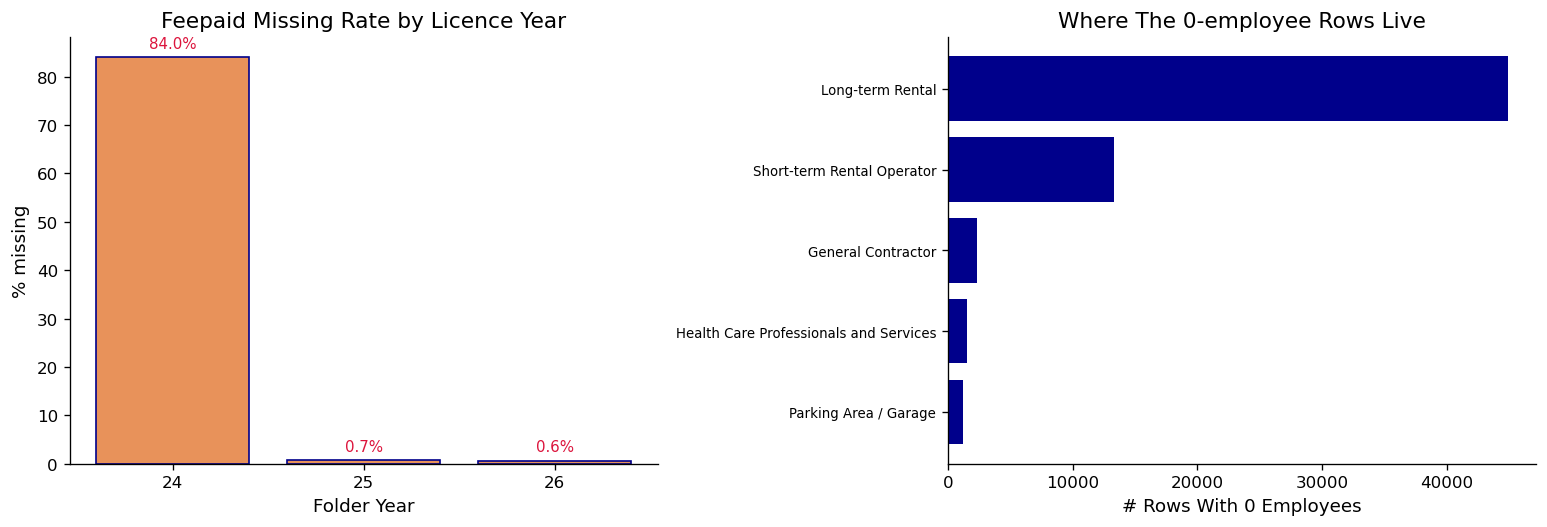

In [4]:
# freepaid
free_paid = df[df["status"] == "Issued"].groupby("folderyear")["feepaid"].apply(
    lambda s: s.isna().mean()
)
print("feepaid missing rate by licence year (Issued only):")
print(free_paid.round(3).to_string())

# numberofemplouees
# BEGIN ChatGPT - "read this carefully why my code is not working?"
number_of_employees = (df["numberofemployees"] == 0).mean()
print(f"\nshare of rows with numberofemployees == 0 : {number_of_employees:.3f}")
print("business types of the 0-employee rows:")
print(df[df["numberofemployees"] == 0]["businesstype"].value_counts().head(5).to_string())
# END

# coordinates
coord = df["lat"].notna().mean()
print(f"\nrows with usable coordinates : {coord:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(free_paid.index, free_paid.values * 100,
            color=ACCENT, edgecolor="darkblue")
axes[0].set_title("Feepaid Missing Rate by Licence Year")
axes[0].set_xlabel("Folder Year")
axes[0].set_ylabel("% missing")
for i, v in enumerate(free_paid.values * 100):
    axes[0].text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=9, color="crimson")

zero_types = df[df["numberofemployees"] == 0]["businesstype"].value_counts().head(5).sort_values()
axes[1].barh(zero_types.index, zero_types.values, color="darkblue")
axes[1].set_title("Where The 0-employee Rows Live")
axes[1].set_xlabel("# Rows With 0 Employees")
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()


- freepaid. So look at the left plot, FY24 is missing 84% while FY 25 and 26 are basically 0 (0.7% and 0.6%). So it is not random but it literally means the city didnt add fees for FY24. If I filled in the blanks with a guessm I would be making up fake fees and that would be very messy. Instead I just drop FY24 later and the problem goes away.
- numberofemployees. 0.358 = ~36% of rows are 0 which looks like mssing data but the right  plot shows the 0s are almost all long term rntal and short ter, rental operator. Those are properties so they do have 0 staff -> So 0 is a real number here not missing. So I dont need to touch this.
- coordinates. Only half the row (0.503 = ~50%) have lat/lon. I cant get them back. So ya I'll drop it

3. Filter to a sensible subset (e.g., status == "Issued") and justify
Before filter I will print the status first so the choice is evidence based. 

In [5]:
# check status befire filtering 
print("status breakdown:")
print(df["status"].value_counts().to_string())
print(f"\nbusinesssubtype missing : {df['businesssubtype'].isna().mean():.1%}")
print(f"postalcode missing : {df['postalcode'].isna().mean():.1%}")

# then filter
STATUS_KEEP = "Issued"
# here I dropped FY24 and FY 25 only keep the most recent year
YEARS_KEEP = ["26"] 
steps= [("raw", len(df))]

df_clean = df[df["status"] == STATUS_KEEP].copy()
steps.append((f"status == '{STATUS_KEEP}'", len(df_clean)))

df_clean = df_clean[df_clean["folderyear"].isin(YEARS_KEEP)]
steps.append((f"folderyear in {YEARS_KEEP}", len(df_clean)))

df_clean = df_clean[df_clean["lat"].notna() & df_clean["lon"].notna()]
steps.append(("has coordinates", len(df_clean)))

print("\nrows surviving each filter:")
for label, n in steps:
    print(f"  {label:<22s} {n:>7,d}  ({n/len(df)*100:4.1f}% of raw)")

status breakdown:
status
Issued                  167008
Pending                  14952
Gone Out of Business     10411
Inactive                  6563
Cancelled                 5173

businesssubtype missing : 89.5%
postalcode missing : 46.6%

rows surviving each filter:
  raw                    204,107  (100.0% of raw)
  status == 'Issued'     167,008  (81.8% of raw)
  folderyear in ['26']    56,942  (27.9% of raw)
  has coordinates         29,025  (14.2% of raw)


I used three filters abd see how the row would survive
- status == 'Issued' (167,008). The breakdown shows the other four statuses are Pending (14952), Gone Out of Business (10411), Inactive (6563) and Cancelled (5173). These are licences that arent active businesses so including them would mean clustering the location of businesses that dont really exist. So I would only keeo Issued
- folderyear in '26' (56,942). This is the decision my freepaid choice was leaning on. Cause keeping FY26 can help to fix freepaid (drops to 0.6% missing so I never impute). It also avoids counting the same business more than once. And lastly, it helps keeping the sample small enough to plot and recluster fast.
- has coordinates (29025). This's actually a biggest single cut which cuts from 56942 down to 29025 (like almost half). There's no way to recover a missing coordinate so I have to let these go.
- There are two col that I checked but dont fix which are businesssubtype missing 89.5% and postalcode missing 46.6%. businesssubtype is missing so much that there's very little real information in it and I dont rely on it. postalcode is missing almost half its values, so if I need a location grouping I'd rather use localarea, which is far more complete.

3. businesstype has ~94 categories, many sparse — decide how to consolidate (e.g., keep the top N, group the rest as "Other")
   So I got a categorical column, businesstype and the spec is warning me it has about 94 values, most of hem sparse. So I'll have to look for how many categories are there really and how are the rows spread across them. I would run value_counts() cause thats the fastest way to see the shape. 

In [6]:
vc = df_clean["businesstype"].value_counts()

print(f"businesstype has {df_clean['businesstype'].nunique()} categories")
print(vc.to_string())

businesstype has 89 categories
businesstype
Health Care Professionals and Services                                 4365
Long-term Rental                                                       3415
Retail Dealer                                                          1998
Legal Services                                                         1753
Restaurant                                                             1628
Beauty Services                                                        1364
Limited Service Food Establishment                                     1279
Business Support Services                                               972
Financial Services                                                      848
Consulting and Management Services                                      790
Real Estate Services                                                    672
Retail Dealer - Food                                                    643
General Contractor                          

This shape is a very long tail, start with some big categories at the top and long tail of tiny ones. However seeing clearly  the tail is thin isnt the same as justifying where to cut it. So I still need a number to justify where to cut and the is the next thing I need to do by turning those raw counts into cumulative coverage. This tells me what share of all business the top n categories actually cover.

In [7]:
cum = vc.cumsum() / vc.sum()

for n in [10, 15, 20, 25]:
    print(f"top {n:2d} categories cover {cum.iloc[n-1]*100:.1f}% of rows")

top 10 categories cover 63.4% of rows
top 15 categories cover 74.0% of rows
top 20 categories cover 80.8% of rows
top 25 categories cover 85.0% of rows


Now I have the numbers I needed. What I'm looking at is how much each jump actually adds. Going from 10 to 15 adds about 10 points, but 15 to 20 only adds about 7, and 20 to 25 only adds about 4. So every time I add more categories, they help less and less. That's the long tail flattening out. The README say to cover about 80% to 90% and top 20 is the smallest cut that gets me into that range at 80.8%. So I keep the top 20 categories and put everything else into one "Other" bucket. This way I'll keep all the categories that actually matter and drop the tiny ones that only describe a handful of businesses each. 

In [8]:
# BEGIN ChatGPT - "fix this why is it returning error"
top_types = vc.head(20).index

df_clean["businesstype_c"] = np.where(
    df_clean["businesstype"].isin(top_types),
    df_clean["businesstype"],
    "Other"
)

other_share = (df_clean["businesstype_c"] == "Other").mean()
print(f"businesstype_c has {df_clean['businesstype_c'].nunique()} categories (20 kept + 'Other')")
print(f"'Other' holds {other_share:.1%} of rows")
print()
print(df_clean["businesstype_c"].value_counts().to_string())
# END

businesstype_c has 21 categories (20 kept + 'Other')
'Other' holds 19.2% of rows

businesstype_c
Other                                            5575
Health Care Professionals and Services           4365
Long-term Rental                                 3415
Retail Dealer                                    1998
Legal Services                                   1753
Restaurant                                       1628
Beauty Services                                  1364
Limited Service Food Establishment               1279
Business Support Services                         972
Financial Services                                848
Consulting and Management Services                790
Real Estate Services                              672
Retail Dealer - Food                              643
General Contractor                                620
Association or Society                            583
Information Communication Technology              563
Wholesale Dealer - Non-Food            

So now I rewrote the column. For every row, if its business type is one of the top 20 then I'll keep it, otherwise I just relabel it Other. I made a new column businesstype_c instead of writing over the original so I still have the raw one if I need it in future.  After doing this I now have 21 categories (the 20 I kept + Other). Other holds 19.2% of the rows, which is what I expected since the top 20 covered 80.8%. And Other ended up at 5575 rows so it sits in the middle of the pack not the biggest bucket which tells me I didnt cut too hard. If Other had swallowed most of the data I'd know my cutoff was too aggressive but it actually looks healthy so yeah!

4. Optional refinement to try: combine businesstype and businesssubtype into a single, more fine-grained industry label where a subtype exists (falling back to businesstype alone where it doesn't). This gives you a sharper industry signal for some categories — worth comparing against businesstype alone.

In [9]:
df_clean["industry"] = np.where(
    df_clean["businesssubtype"].notna(),
    df_clean["businesstype"] + " - " + df_clean["businesssubtype"],
    df_clean["businesstype"]
)

print(f"businesstype alone : {df_clean['businesstype'].nunique()} categories")
print(f"industry (type+sub): {df_clean['industry'].nunique()} categories")
print(f"subtype present on : {df_clean['businesssubtype'].notna().mean():.1%} of rows")
print()
print("examples where a subtype got added:")
print(df_clean[df_clean["businesssubtype"].notna()][["businesstype", "businesssubtype", "industry"]].head(50).to_string(index=False))

businesstype alone : 89 categories
industry (type+sub): 145 categories
subtype present on : 19.4% of rows

examples where a subtype got added:
 businesstype             businesssubtype                                  industry
Artist Studio   Artist Live / Work Studio Artist Studio - Artist Live / Work Studio
      Caterer              Catering Truck                  Caterer - Catering Truck
      Caterer              Catering Truck                  Caterer - Catering Truck
      Caterer              Catering Truck                  Caterer - Catering Truck
      Caterer              Catering Truck                  Caterer - Catering Truck
   Restaurant Class 1 with liquor service  Restaurant - Class 1 with liquor service
   Restaurant Class 1 with liquor service  Restaurant - Class 1 with liquor service
   Restaurant Class 1 with liquor service  Restaurant - Class 1 with liquor service
   Restaurant Class 1 with liquor service  Restaurant - Class 1 with liquor service
   Restaurant Cla

So based on the suggestion of the README, I combined businesstype and businesssubtype into a single new col and called iy industry. So basically, where a row has a subtype it gets a finer label like Caterer -> Caterer - Catering Truck and where it doesnt fit then just keep the normal type. One more example is the Restaurant. On its own it's just one category but the subtype splits it into Restaurant - Class 1 with liquor service and Restaurant - Class 1 no liquor service which is cool to know restaurant serve alcohol or not. Comparing the row, businesstype alone has 89 categories and the combined industry label has 145 so the refinement adds 56 more categories. But only 19.4% of my rows actually have a subtype, so the other 80% look exactly the same as before. And more categories isn't free, it means a bigger and sparser feature space with some categories describing only a few rows each. So the finer label is sharper for the fifth of the data that has a subtype but costs me more sparsity overall. I keep both columns so I can try either but businesstype_c (my top 20 version) is my main industry feature since it's way cleaner. 

In [10]:
# print shape and confirm the col my features will use and save it so I wont have to rerun all everytime.
print(f"Final cleaned dataset: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
print()
print("completeness of the columns I'll actually use:")
for col in ["lat", "lon", "numberofemployees", "feepaid", "businesstype_c", "localarea"]:
    print(f" {col:<18s} {df_clean[col].notna().mean()*100:5.1f}% present")
df_clean.to_parquet("licences_clean.parquet", index=False)
print("\nsaved to licences_clean.parquet")

Final cleaned dataset: 29,025 rows, 29 columns

completeness of the columns I'll actually use:
 lat                100.0% present
 lon                100.0% present
 numberofemployees  100.0% present
 feepaid             99.2% present
 businesstype_c     100.0% present
 localarea          100.0% present

saved to licences_clean.parquet


A1 Report. 

Starting from 204107 raw records I made a few cleaning decisions and ended up with 29025 clean business licences to work with. I dropped geom and geo_point_2d because they were empty or duplicates. I kept only status Issued so I'm not clustering businesses that dont really exist and only FY26 which fixed the feepaid missingness on its own and stopped the same business being counted across years. I dropped rows with no coordinates because I cant place them on a map and cant get them back. I left numberofemployees alone because the zeros are real (rental properties) and I consolidated businesstype down to the top 20 + Other (= 21) to cut the long sparse tail. I also built an optional finer industry label from type plus subtype to compare against. My cleaned data has complete coordinates, complete localarea, near-complete feepaid, and a tidy 21 category business type column. Lastly, I saved all to a file so I dont have to rerun the whole load each time.

A2 — Location-only clustering: K-means vs. DBSCAN

In [11]:
# load the cleaned data, pull out lat/lon as the clustering input
df = pd.read_parquet("licences_clean.parquet")

coords = df[["lon", "lat"]].to_numpy()
print(f"clustering on {coords.shape[0]:,} businesses, {coords.shape[1]} columns (lon, lat)")
print(f"lon range: {coords[:,0].min():.3f} to {coords[:,0].max():.3f}")
print(f"lat range: {coords[:,1].min():.3f} to {coords[:,1].max():.3f}")

clustering on 29,025 businesses, 2 columns (lon, lat)
lon range: -123.219 to -123.024
lat range: 49.201 to 49.296


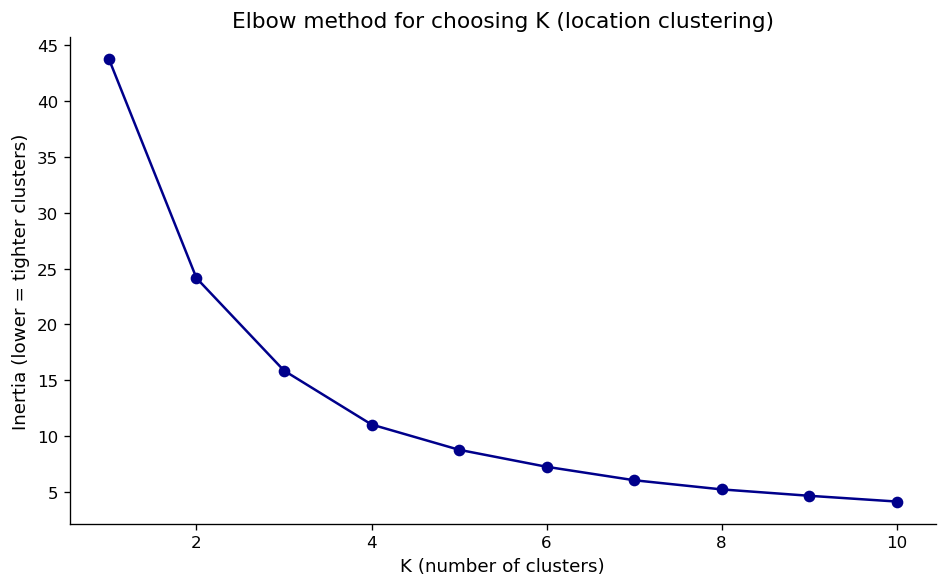

K= 1  inertia=43.762
K= 2  inertia=24.148
K= 3  inertia=15.866
K= 4  inertia=11.037
K= 5  inertia=8.773
K= 6  inertia=7.251
K= 7  inertia=6.046
K= 8  inertia=5.225
K= 9  inertia=4.653
K=10  inertia=4.137


In [12]:
# run K means for a range of K and for each K record the inertia 
# then look for the point where the drop flattens out 

K_RANGE = range(1, 11)
inertias = []
for k in K_RANGE:
    km= KMeans(n_clusters= k, random_state=42, n_init=10)
    km.fit(coords)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_RANGE), inertias, "o-", color="darkblue")
ax.set_title("Elbow method for choosing K (location clustering)")
ax.set_xlabel("K (number of clusters)")
ax.set_ylabel("Inertia (lower = tighter clusters)")
plt.tight_layout()
plt.show()

for k, inertia in zip(K_RANGE, inertias):
    print(f"K={k:2d}  inertia={inertia:.3f}")



In [13]:
# turn the list into a table to see how much each extra K buys
elbow = pd.DataFrame({"K": list(K_RANGE), "inertia": inertias})
elbow["drop"] = -elbow["inertia"].diff()
print(elbow.round(3).to_string(index=False))

 K  inertia   drop
 1   43.762    NaN
 2   24.148 19.615
 3   15.866  8.282
 4   11.037  4.829
 5    8.773  2.264
 6    7.251  1.522
 7    6.046  1.205
 8    5.225  0.821
 9    4.653  0.572
10    4.137  0.517


Now I have the table that can read the elbow (the point where the drops flatten out). The way to find it is to look at how much each extra cluster actually helps which is the drop col. The first two drops are big, 19.615 then 8.282 so going from 1 to 3 clusters is capturing real structure. Going from 3 to 4 still helps a decent amt (4.829). But after 4 the drops get small (2.264 then 1.522) and from there they stay real small and about the same. Oncethe drops flatten out like that I went past the elbow each cluster is just splitting a blob I already have instead of finding something new. 
So I would say the bend is arounf K=4 which is where the big gains stop. 
Not much important but I noticed the curve is a very gentle curve not a sharp corner (well except it is abit sharp from K1 - K2 but it is not significant). I think this could mean something but not sure at this moment.

In [14]:
# fit Kmeans with K=4

K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(coords)

print(f"K-means with K={K}, businesses per cluster:")
print(df["kmeans_cluster"].value_counts().sort_index().to_string())

K-means with K=4, businesses per cluster:
kmeans_cluster
0     5659
1    16177
2     2699
3     4490


It came out kinda uneven. Cluster 1 has 16177 businesses which is more than half of everything while cluster 2 only has 2699. This could mean Kmeans cuts the mao into 4 roughly even shaped regions but businesses arent spread evenly across the mapp/ So one region landed right on the busy dense part of the city and grabbed a huge chunk (cluster 1) and the others cover the less dense areasa around it with fewer businesses. So I'll leave it as it is cause this is not something to fix. 

In [15]:
# next is DBSCAN
# convert lon/lat to radians
# convert my eps from km into radians of earth
# fit DBSCAN

EPS_KM = 0.2
MIN_SAMPLES = 20
EARTH_RADIUS_KM = 6371.0
coords_rad = np.radians(coords)
eps_rad = EPS_KM / EARTH_RADIUS_KM
dbscan = DBSCAN(eps=eps_rad, min_samples= MIN_SAMPLES, metric= "haversine")
df["dbscan_cluster"] = dbscan.fit_predict(coords_rad)
n_clusters = df["dbscan_cluster"].nunique() - (1 if -1 in df["dbscan_cluster"].values else 0)
n_noise = (df["dbscan_cluster"] == -1).sum()

print(f"DBSCAN with eps={EPS_KM}km, min_samples={MIN_SAMPLES}")
print(f"clusters found : {n_clusters}")
print(f"noise points : {n_noise:,} ({n_noise/len(df)*100:.1f}% of businesses)")

DBSCAN with eps=0.2km, min_samples=20
clusters found : 41
noise points : 594 (2.0% of businesses)


I ran DBSCAN on the same coordinates. Instead of me telling it how many clusters to make like Kmeans, DBSCAN figures that out on its own from two settings, eps (how close businesses have to be to count as neighbors) and min_samples (how many neighbors a spot needs to count as a dense area). Anything that isnt in a dense enough area gets labeled noise. My first try was eps=0.2km and min_samples=20, and it found 41 clusters with only 594 points (2%) as noise. Straight away this is really different from Kmeans. Kmeans gave me exactly 4 clusters and forced every business into one of them. DBSCAN found 41 little dense pockets and let a small number of businesses be noise, belonging to nothing. But 41 clusters is a bit lot and almost nothing got called noise. That tells me that my settings are too loose, DBSCAN is picking up tons of tiny pockets instead of a few meaningful busy zones. A map with 41 colors would be really hard to read and hard to compare to Kmeans's clean 4 regions. So I need to tune the settings to get fewer, bigger clusters that I can actually recognize on a map.

In [16]:
# grid of eps (km) and min_samples values
# for each combo, run DBSCAN and record clusters found + noise %

# BEGIN ChatGPT "I tried to grid of eps (km) and min-samples values but it return an error, explain why"
eps_options = [0.2, 0.3, 0.4, 0.5]
min_samples_options = [20, 30, 50]

results = []
for eps_km in eps_options:
    for ms in min_samples_options:
        labels = DBSCAN(
            eps=eps_km / EARTH_RADIUS_KM,
            min_samples=ms,
            metric="haversine"
        ).fit_predict(coords_rad)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        results.append({
            "eps_km": eps_km,
            "min_samples": ms,
            "clusters": n_clusters,
            "noise_pct": round(n_noise / len(labels) * 100, 1)
        })
# ENDS

sweep = pd.DataFrame(results)
print(sweep.to_string(index=False))

 eps_km  min_samples  clusters  noise_pct
    0.2           20        41        2.0
    0.2           30        36        3.2
    0.2           50        30        6.1
    0.3           20        18        1.1
    0.3           30        18        1.5
    0.3           50        19        3.0
    0.4           20        10        0.6
    0.4           30        11        0.8
    0.4           50        11        1.6
    0.5           20         3        0.2
    0.5           30         3        0.4
    0.5           50         7        0.6


Reading the table the pattern is clear as eps gets bigger the clusters merge together so I go from 41 down to 36, 30 then around 18, then about 10 and finally just 3 at the widest setting. One thing that stands out is that noise stays really low everywhere. It never even reaches 7%. I think that's a real finding about my data cause businesses in Vancouver are packed densely almost everywhere in the city so barely anything ends up stranded as an outlier no matter how I set the settings. So because of this I'll pick based on getting a readable and meaningful number of clusters instead. I'll go with eps=0.4km and min_samples=30, which gives 11 clusters and 0.8% noise. 11 is a good middle ground it's more detailed than Kmeans's 4 regions so the comparison is interesting but it's not the messy 41 colors I started with so it's better for eyes too.

In [17]:
# Fit the DBSCAN with chosen setting 

EPS_KM = 0.4
MIN_SAMPLES = 30

df["dbscan_cluster"] = DBSCAN(
    eps=EPS_KM/ EARTH_RADIUS_KM,
    min_samples=MIN_SAMPLES,
    metric="haversine"
).fit_predict(coords_rad)

n_clusters = df["dbscan_cluster"].nunique() - (1 if -1 in df["dbscan_cluster"].values else 0)
n_noise = (df["dbscan_cluster"] == -1).sum()
print(f"DBSCAN locked: eps={EPS_KM}km, min_samples={MIN_SAMPLES}")
print(f"  clusters: {n_clusters}, noise: {n_noise:,} ({n_noise/len(df)*100:.1f}%)")

DBSCAN locked: eps=0.4km, min_samples=30
  clusters: 11, noise: 239 (0.8%)


It found 11 clusters and marked 239 businesses (0.8%) as noise. So now these cluster labels are saved on my data and ready to plot.

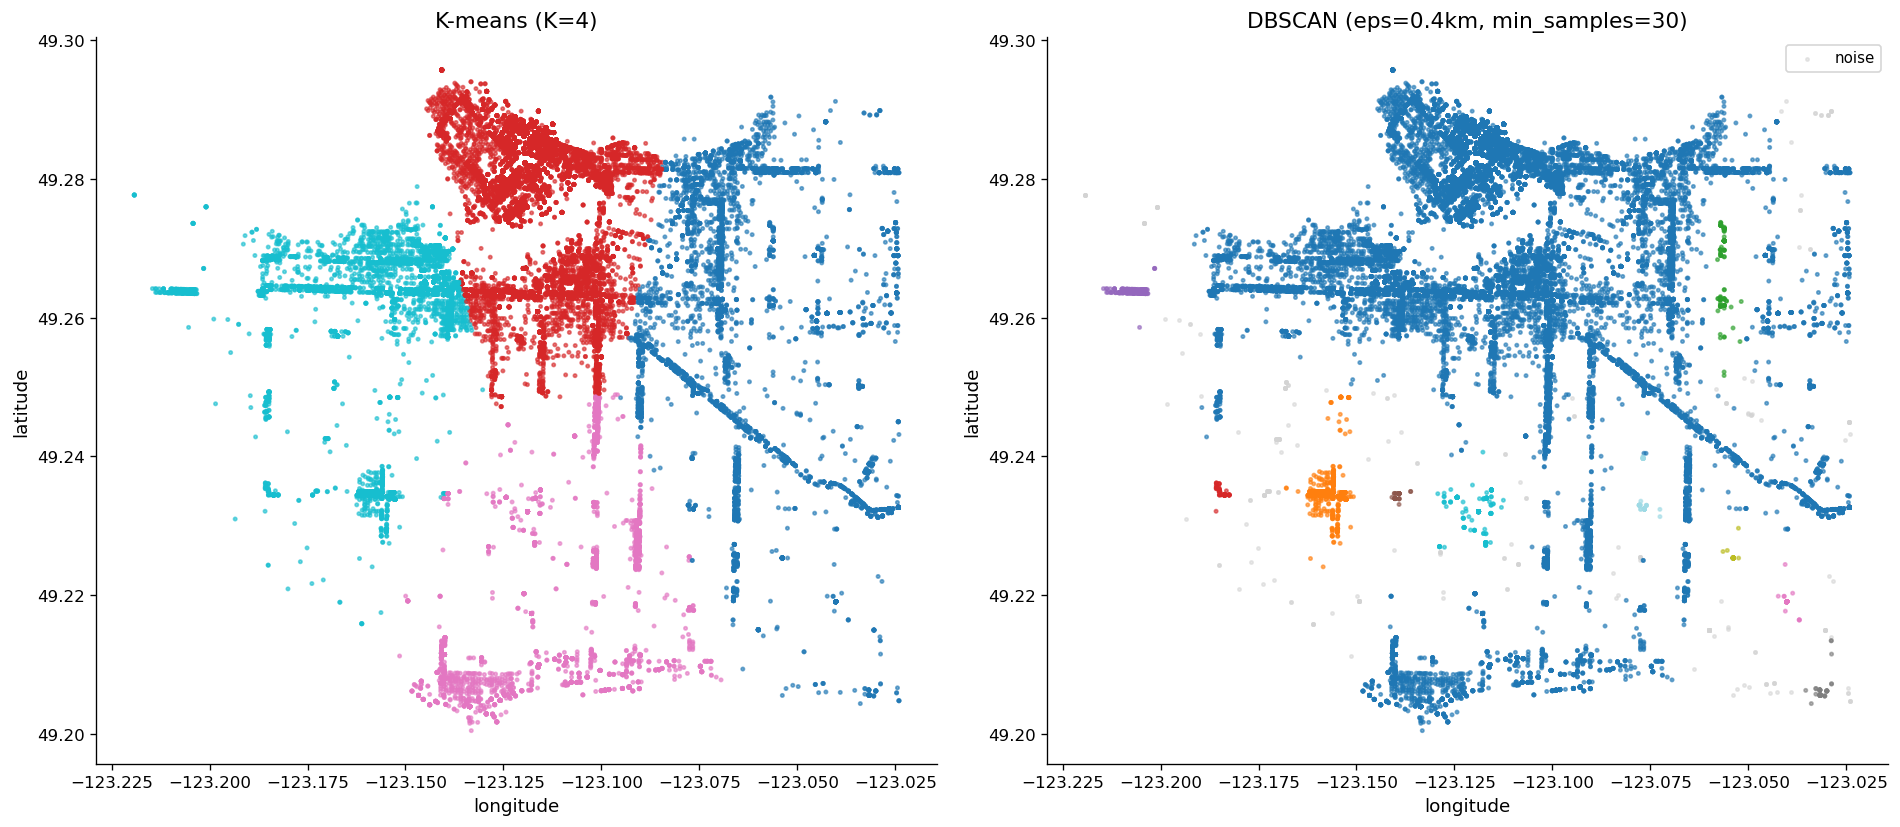

In [18]:
# last step if to plot both methods side by side

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# left: Kmeans
axes[0].scatter(df["lon"], df["lat"], c=df["kmeans_cluster"],
                cmap="tab10", s=4, alpha=0.6)
axes[0].set_title(f"K-means (K={K})")
axes[0].set_xlabel("longitude")
axes[0].set_ylabel("latitude")

# right: DBSCAN
noise = df["dbscan_cluster"] == -1
axes[1].scatter(df.loc[noise, "lon"], df.loc[noise, "lat"],
                c="lightgray", s=4, alpha=0.5, label="noise")
axes[1].scatter(df.loc[~noise, "lon"], df.loc[~noise, "lat"],
                c=df.loc[~noise, "dbscan_cluster"], cmap="tab20", s=4, alpha=0.6)
axes[1].set_title(f"DBSCAN (eps={EPS_KM}km, min_samples={MIN_SAMPLES})")
axes[1].set_xlabel("longitude")
axes[1].set_ylabel("latitude")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

Woah. Side note, I can see the Vancouver map here which is amazing. 

Markdown for the README requirement.
1. How do the K-means clusters map onto real Vancouver geography?
   They line up with real parts of the city pretty well. The big red cluster in the middle is the busy downtown and it makes sense that it has the most businesses since thats the center of the city. The cyan cluster on the left is the west side, the pink cluster at the bottom is the south and the blue cluster on the right east side. So ya, the 4 clusters match areas I'd recognize like center west south east. The red downtown cluster grabbing over half the businesses shows the city isn't spread evenly, the center is way busier than the edges.
2. How do the DBSCAN clusters compare, and what does noise mean?
   The right side is a bit different. Instead of 4 regions, one giant blue cluster takes over almost the entire busy middle of the city. Thats prolly because the whole dense part is connected, there's no real gap breaking it up. So DBSCAN just treats it all as one cluster. There are few small colored sitting on the alone around like the organge on the bottom left, some purple on the very left end etc.
   So both put lots of businesses in the dense center. However, Kmeans draws a line straight through that center to make 4 pieces but DBSCAN wont split it because there's no gap there to split on. This comes down to what each one assumes. Kmeans assumes clusters are round even blobs and forces every point into one so it always gives me exactly 4 regions. DBSCAN assumes clusters are dense areas separated by empty spce so it only splits where there's really a gap and it's allowed to leave points out.
   The noise points (239 - 0.8%) are the businesses sitting alone in sparse spots without enough neighbors nearby to join a cluster. Kmeans had no choice but to color those same lonely dots and fold them into a region anyway but DBSCAN just marks them as noise. There's so little noise here because businesses are packed densely almost everywhere in the city so barely any of them end up truly stranded.
   

A3 — Feature-based clustering: Size, Industry, Lifecycle
BEGIN - ChatGPT explain the question and tell me step by step what i need to do
END

The steps A3 breaks into:

1. Build the Size features (mostly ready, employees and feepaid already exist)
2. Build the Lifecycle features (this is where the timezone fix and the cyclic month encoding happen)
3. Build the Industry features (turn your businesstype_c categories into numbers via one-hot encoding)
4. Combine all of them and scale (StandardScaler, because now the features are in wildly different units)
5. Run K-means on the combined feature set
6. Run PCA to project down to 2D and plot the clusters
7. Write the interpretation, what do the clusters represent, and how is this different from A2's geographic clusters?

       numberofemployees       feepaid
count       29025.000000  28796.000000
mean           20.094574    685.298167
std           112.321309   1521.583385
min             0.000000      2.000000
25%             1.000000    277.000000
50%             3.000000    277.000000
75%             9.000000    577.000000
max          4000.000000  63722.000000

missing: numberofemployees 0.0%,feepaid 0.8%


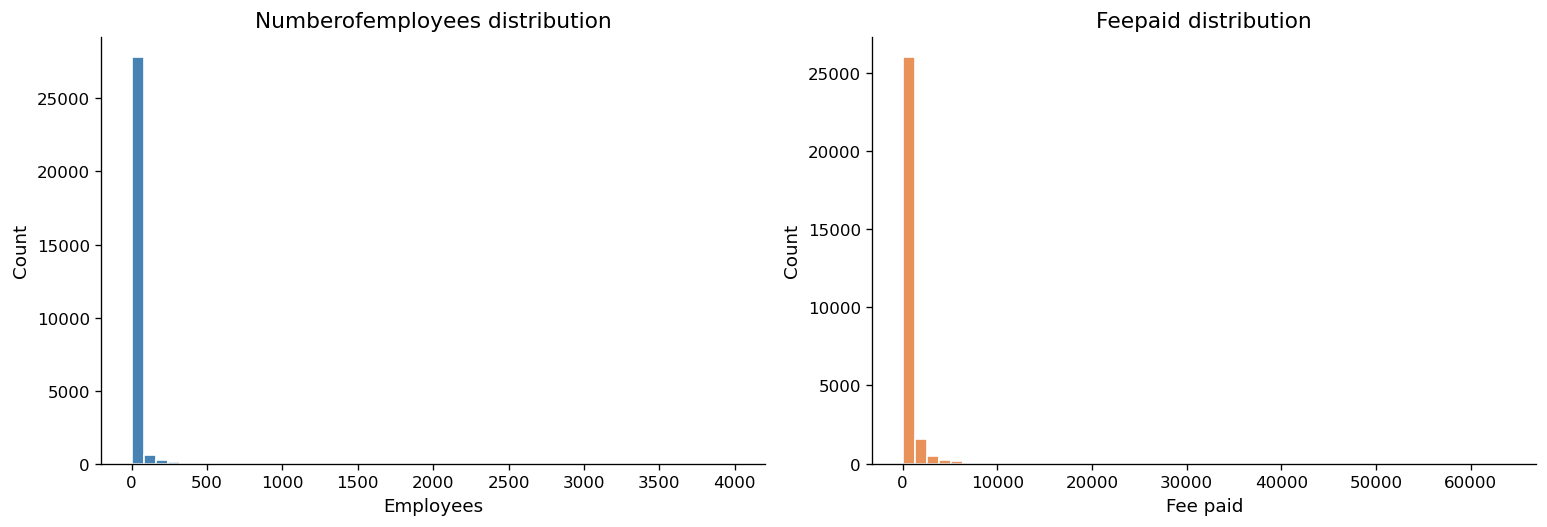

In [19]:
# buil the size features
# two Size features: numberofemployees and feepaid
# plot distribution

size_cols = ["numberofemployees", "feepaid"]
print(df[size_cols].describe().to_string())
print(f"\nmissing: numberofemployees {df['numberofemployees'].isna().mean():.1%},"
      f"feepaid {df['feepaid'].isna().mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df["numberofemployees"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Numberofemployees distribution")
axes[0].set_xlabel("Employees")
axes[0].set_ylabel("Count")

axes[1].hist(df["feepaid"].dropna(), bins=50, color=ACCENT, edgecolor="white")
axes[1].set_title("Feepaid distribution")
axes[1].set_xlabel("Fee paid")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

The two size features are number are employees and fee paid. When I look at them both are really lopsided. For employees, half the businesses have 3 or fewer but the biggest has 4000. Fee paid is the same most are around 277 but the biggest is 637222. So almost all businesses are small and just a few are huge. If I leave the numbers like this those few giant businesses are so big they take over and the model stops paying attention to all the normal ones. To fix it I'll use a log transform to see the difference.


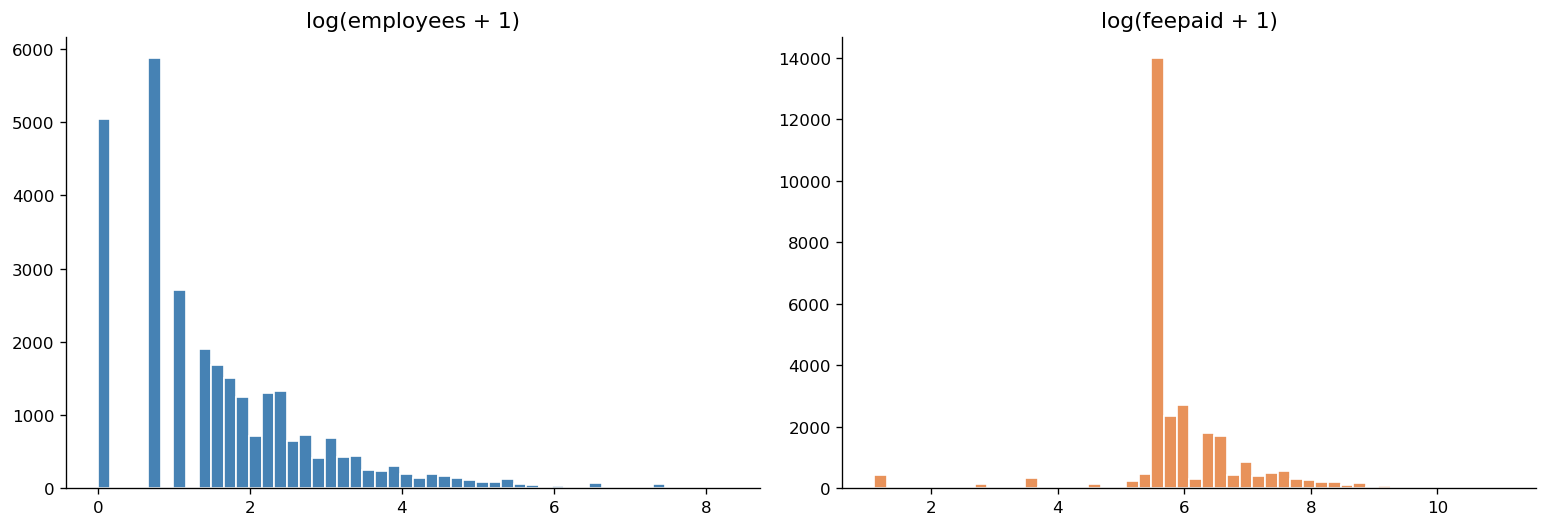

In [20]:
df["feepaid"] = df["feepaid"].fillna(df["feepaid"].median())
df["emp_log"] = np.log1p(df["numberofemployees"])
df["fee_log"] = np.log1p(df["feepaid"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df["emp_log"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("log(employees + 1)")
axes[1].hist(df["fee_log"], bins=50, color=ACCENT, edgecolor="white")
axes[1].set_title("log(feepaid + 1)")
plt.tight_layout()
plt.show()

After the log transform both features look much better. Employees used to be one big spike but now its spread out nicely. So now I can actually see the differences between normal businesses.

In [21]:
# 2. Build the Lifecycle features (this is where the timezone fix and the cyclic month encoding happen)

df["issueddate"] = df["issueddate"].dt.tz_localize(None)
df["duration_days"] = (df["expireddate"] - df["issueddate"]).dt.days
df["duration_days"] = df["duration_days"].fillna(df["duration_days"].median())
month = df["issueddate"].dt.month
df["month_sin"] = np.sin(2 * np.pi * month / 12)
df["month_cos"] = np.cos(2 * np.pi * month / 12)
df["revision"] = pd.to_numeric(df["licencerevisionnumber"], errors="coerce").fillna(0)

print("Lifecycle features:")
print(df[["duration_days", "month_sin", "month_cos", "revision"]].describe().round(2).to_string())

Lifecycle features:
       duration_days  month_sin  month_cos  revision
count       29025.00   28982.00   28982.00  29025.00
mean          363.37       0.06       0.73      0.04
std            52.44       0.48       0.48      0.19
min            14.00      -0.87      -1.00      0.00
25%           350.00      -0.50       0.87      0.00
50%           377.00      -0.00       0.87      0.00
75%           401.00       0.50       1.00      0.00
max           601.00       1.00       1.00      2.00


For lifecycle I built three things. Duration is how long the licence lasts (expire date minus issue date) and it came out to a median of 377 days, so about a year which makes sense for a yearly business licence. I had to strip the timezone off the issue date first or the subtraction wouldn't work. The trickier one is the month the licence was issued. I cant just use the month number 1 to 12, because then dec and jan would look really far apart when they're actually right next to each other on the calendar. So I wrapped the month onto a circle using sin and cos, which puts dec and jan next to each other like they should be. That turns one month into two numbers that both stay between -1 and 1. The last one is the revision number, how many times the licence was changed. It's stored as text so I turned it into a number. It's almost all zeros though so it wont do much but the README asked for it so I kept it in.

In [22]:
# 3. Build the Industry features (turn your businesstype_c categories into numbers via one-hot encoding)

industry = pd.get_dummies(df["businesstype_c"], prefix="ind").astype(int)
print(f"Industry: {df['businesstype_c'].nunique()} categories became {industry.shape[1]} columns")
print(industry.head(3).to_string())

Industry: 21 categories became 21 columns
   ind_Architectural and Engineering Services  ind_Association or Society  ind_Beauty Services  ind_Business Support Services  ind_Consulting and Management Services  ind_Financial Services  ind_General Contractor  ind_Health Care Facility  ind_Health Care Professionals and Services  ind_Information Communication Technology  ind_Legal Services  ind_Limited Service Food Establishment  ind_Long-term Rental  ind_Non-Food Manufacturer Assembler and Processor  ind_Other  ind_Parking Area / Garage  ind_Real Estate Services  ind_Restaurant  ind_Retail Dealer  ind_Retail Dealer - Food  ind_Wholesale Dealer - Non-Food
0                                           0                           0                    0                              0                                       0                       0                       0                         0                                           0                                         0                

Industry is the type of business which I already have in businesstype_c. But it's text and the model only takes numbers so I have to turn the categories into numbers. I can't just number them like Restaurant=1, Retail=2, Legal=3 because then the model would think they have an order like Legal is somehow bigger than Restaurant which makes no sense. Business types aren't in any order. So instead I use one-hot encoding. This makes one column for each business type and each column is just a 0 or 1 saying "is this business that type or not". A restaurant gets a 1 in the Restaurant column and 0 everywhere else. That way no type is treated as bigger than another they're all equal. My 21 categories became 21 columns and each business has exactly one 1 since every business is one type.

In [23]:
# 4. Combine all of them and scale (StandardScaler, because now the features are in wildly different units)
# combine the three feature groups into one table 
# fill the mssing values
# scale everything with StandardScaler

size_feats = df[["emp_log", "fee_log"]]
lifecycle_feats = df[["duration_days", "month_sin", "month_cos", "revision"]]
features = pd.concat([size_feats, lifecycle_feats, industry], axis=1)
features = features.fillna(0)

print(f"Combined feature table: {features.shape[0]:,} rows, {features.shape[1]} columns")

X = StandardScaler().fit_transform(features)
print(f"Scaled matrix shape: {X.shape}")
print(f"mean after scaling: {X.mean():.3f} (should be ~0)")
print(f"std after scaling: {X.std():.3f} (should be ~1)")

Combined feature table: 29,025 rows, 27 columns
Scaled matrix shape: (29025, 27)
mean after scaling: 0.000 (should be ~0)
std after scaling: 1.000 (should be ~1)


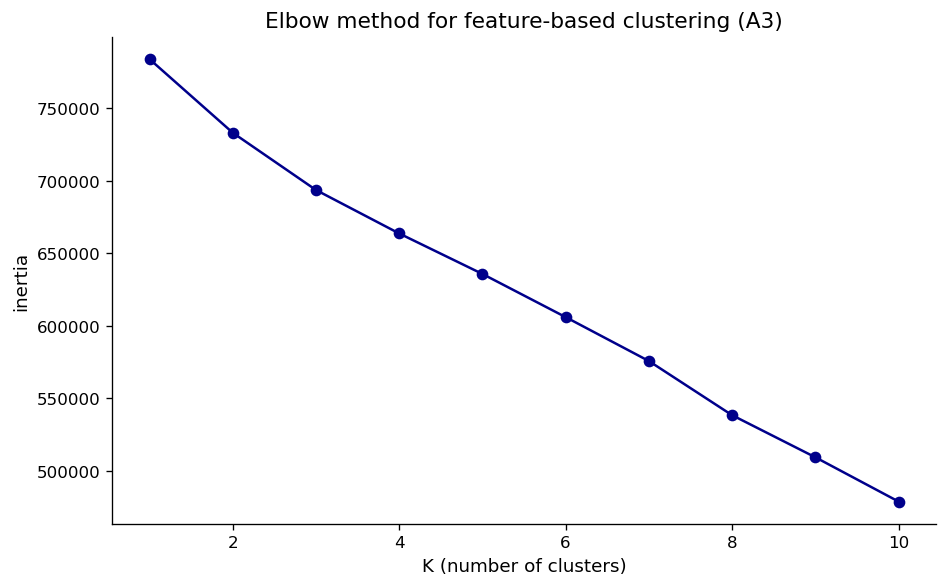

 K  inertia    drop
 1 783675.0     NaN
 2 732948.8 50726.2
 3 693508.1 39440.7
 4 663570.1 29938.0
 5 635681.8 27888.3
 6 605936.9 29744.9
 7 575689.4 30247.5
 8 538381.7 37307.7
 9 509391.3 28990.5
10 478892.6 30498.7


In [24]:
# 5. Run K-means on the combined feature set

K_RANGE_A3 = range(1, 11)
inertias_a3 = []
for k in K_RANGE_A3:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias_a3.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_RANGE_A3), inertias_a3, "o-", color="darkblue")
ax.set_title("Elbow method for feature-based clustering (A3)")
ax.set_xlabel("K (number of clusters)")
ax.set_ylabel("inertia")
plt.tight_layout()
plt.show()

elbow_a3 = pd.DataFrame({"K": list(K_RANGE_A3), "inertia": inertias_a3})
elbow_a3["drop"] = -elbow_a3["inertia"].diff()
print(elbow_a3.round(1).to_string(index=False))

Same as A2, I ran Kmeans for a bunch of K values and looked at the drops to find the elbow. But this time there isn't a clear elbow. The drops start a bit bigger (50k, 39k, 30k) but then they just stay around 28k to 37k the whole way down, they never suddenly go small and flat like they did in A2. I think that's not a mistake. It means businesses dont fall into a few clean separate groups they're more of a smooth spread since size, age and industry all vary bit by bit. So there's no perfect K here. The biggest drops happen up to K=4 and after that each new cluster only buys about the same amount. So I'll go with K=4.

In [25]:
# fit Kmeans at K=4

K_A3 = 4

kmeans_a3 = KMeans(n_clusters=K_A3, random_state=42, n_init=10)
df["feature_cluster"] = kmeans_a3.fit_predict(X)

print(f"K-means on features (K={K_A3}), businesses per cluster:")
print(df["feature_cluster"].value_counts().sort_index().to_string())

K-means on features (K=4), businesses per cluster:
feature_cluster
0     1594
1     3640
2     4990
3    18801


They came out really uneven, cluster 3 has 18801 businesses while cluster 0 only has 1594. So it found one big group of normal businesses and three smaller special ones.

7. Run PCA to project down to 2D and plot the clusters
   The businesses line in 27 dim spaces (27 features). I cant plot 27 dim so I need to squish down to 2 but I also cant pick 2 features and ignore the rest. So Using PCA to find 2 combined directions that capture the most spread in the data. 

PC1 captures 8.8% of the variation
PC2 captures 7.0% of the variation
together: 15.8%


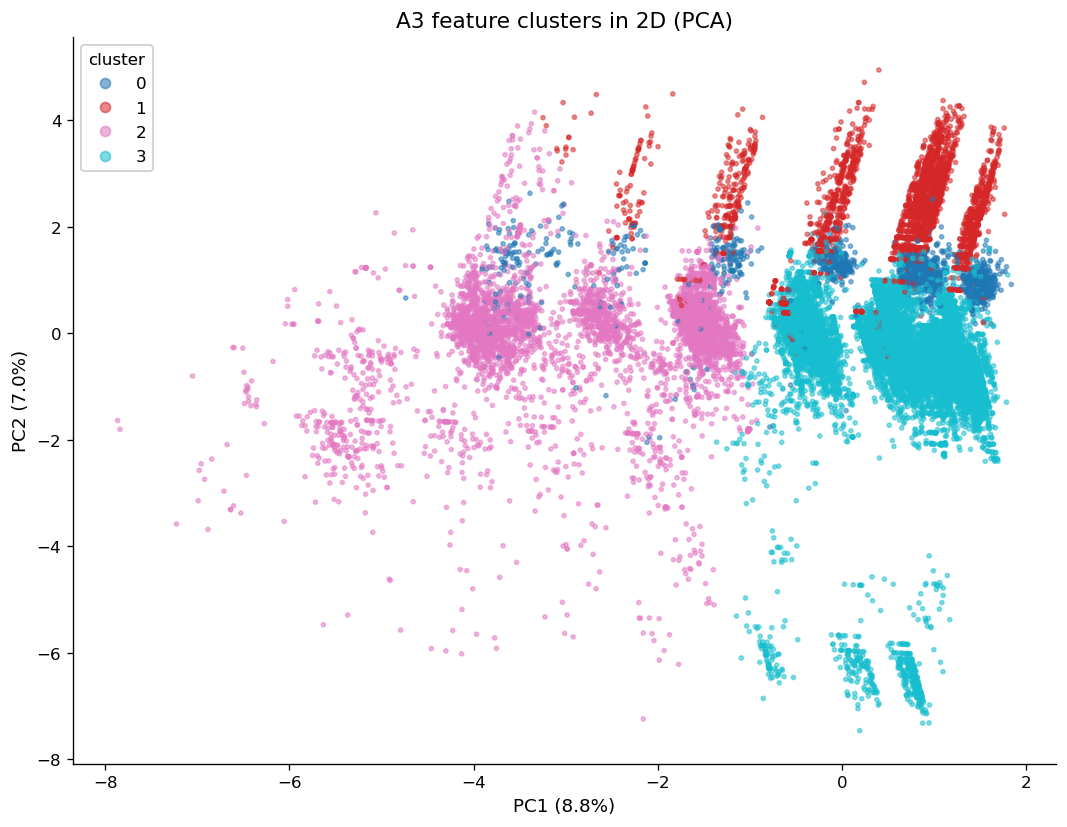

In [26]:
# use PCS to squish down 2 dim
# report how much of the total variations
# plot


pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(X)
var = pca.explained_variance_ratio_
print(f"PC1 captures {var[0]:.1%} of the variation")
print(f"PC2 captures {var[1]:.1%} of the variation")
print(f"together: {var.sum():.1%}")
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(coords_2d[:, 0], coords_2d[:, 1],
                     c=df["feature_cluster"], cmap="tab10", s=6, alpha=0.5)
ax.set_title("A3 feature clusters in 2D (PCA)")
ax.set_xlabel(f"PC1 ({var[0]:.1%})")
ax.set_ylabel(f"PC2 ({var[1]:.1%})")
legend = ax.legend(*scatter.legend_elements(), title="cluster", loc="best")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

Even though PC1 and PC2 only capture 15.8% together the colors still separate into their own areas instead of being one mixed cloud so Kmeans did find real groups. The plot shows the 4 groups are separate but not what they are. To name them I need to look at what's average inside each cluster, how big are the businesses, how long are the licences and what industries dominate. Comparing those across the 4 clusters is what reveals the profile of each.

In [27]:
# for the size features, show each cluster's avg compared to the overall avg.
# for each cluster show most com industries

profile_cols = ["numberofemployees", "feepaid", "duration_days", "revision"]
overall_mean = df[profile_cols].mean()
overall_std = df[profile_cols].std()
cluster_means = df.groupby("feature_cluster")[profile_cols].mean()
cluster_z = ((cluster_means - overall_mean) / overall_std).round(2)

print("How each cluster compares to average (+ = above, - = below):")
print(cluster_z.to_string())
print("\ncluster sizes:")
print(df["feature_cluster"].value_counts().sort_index().to_string())

print("\ntop industries per cluster:")
for c in sorted(df["feature_cluster"].unique()):
    top = df[df["feature_cluster"] == c]["businesstype_c"].value_counts().head(3)
    print(f"\ncluster {c}:")
    print(top.to_string())

How each cluster compares to average (+ = above, - = below):
                 numberofemployees  feepaid  duration_days  revision
feature_cluster                                                     
0                             0.01     0.62           0.01     -0.06
1                            -0.18     0.79           0.20     -0.14
2                             0.03    -0.15          -1.68      0.70
3                             0.02    -0.16           0.41     -0.15

cluster sizes:
feature_cluster
0     1594
1     3640
2     4990
3    18801

top industries per cluster:

cluster 0:
businesstype_c
Restaurant    1594

cluster 1:
businesstype_c
Long-term Rental         3284
Parking Area / Garage     356

cluster 2:
businesstype_c
Other                                     1278
Health Care Professionals and Services     942
Retail Dealer                              435

cluster 3:
businesstype_c
Other                                     4297
Health Care Professionals and Services    342

- Cluster 0 (1,594) is restaurants. It's literally 100% restaurants, so this group got pulled out just because of its industry.
- Cluster 1 (3,640) is property businesses, mostly Long-term Rental plus some Parking. It has the highest fees but the lowest employees, which makes sense, rentals and parking pay a licence fee but don't have staff.
- Cluster 2 (4,990) is the interesting one. It's not about industry, it's about lifecycle. These businesses have really short licence durations (way below average) and got revised more than the others. The industries are mixed. So this is a short or changed licence group.
- Cluster 3 (18,801) is the big normal group. Everything is close to average with a slightly longer full year licence, and it's a broad mix of industries. This is the typical everyday business.

What do the resulting clusters seem to represent? Does this differ from the purely geographic clustering in A2?
This is really different from A2. In A2 I clustered on location so the groups were places, downtown west south east. Here I clustered on what a business actually is (its size, lifecycle, and industry) so the groups are business types instead of places, like restaurants, rentals, short-licence businesses. A2 told me where businesses are. A3 tells me what kind of business they are. Two businesses right next to each other downtown would be in the same A2 cluster, but if one is a restaurant and the other is a rental, they land in totally different A3 clusters. So the two clusterings answer completely different questions about the same businesses.


Part B — Neighborhood/Zipcode Similarity Explorer (Streamlit app)
B1. Step 1. I chose localarea (25 named neighborhoods) — cleaner, near-complete coverage. The reason is as mention above, because of the coverage. From A1 check, postalcode was about  47% missing but localarea is almost complete so if I use FSA I'd lose almost half businesses. FSA is also more noisy since it splits fewer business across more little areas, and the spec warns about thin area giving bad percentages. localarea gives me fewwer but bigger areas so the percentage are steady. It's true that FSA is more detailed but at 54% coverage that detail is mostly noise so no.

In [28]:
cols_for_app = ["localarea", "businesstype", "lat", "lon"]
df[cols_for_app].to_csv("vancouver_businesses.csv", index=False)
print(f"saved {len(df):,} businesses")

saved 29,025 businesses


Cluster 0 is Kitsilano, West End, South Cambie and Shaughnessy (I've never heard of this!!). These got grouped because they have a lot of Long-tearm Rental. There are busy areas with alot of apartments so makes sense to have lots of rental licences
Cluster 1 is the big group with 12 areas like Kerrisdale, Oakridge, Killarney and Dunbar. Their top type is Health Care. These are quiet, spread-out neighborhoods where businesses are mostly normal everyday things like clinics/shops etc. No much to say so they just stay in group together. 
Cluster 2 is Mount Pleasant, Grandview-Woodland, Strathcona, Marpole and Sunset. This is a middle group with a mix rentals and health care but noting extreme.
Cluster 3 is downtown. t's the only area in its group. That kinda makes sense because its top business types are Legal Services and Business Support Services which no other area has. Downtown is the office and business part of the city, full of law firms and company services so it doesn't look like anywhere else.

Does it make sense? Ya I would say. The groups match what I'd expect about the city. Partically, downtown being its own thing really match with what I know about this city. 

Anything surprising? Nothing much to be honest. I found some places like Shaughnessy that I didnt know it is in Vancouver but more than that I would say not much of these make me very very surprised. I made some search about Shaughnessy and found out it is a quiet fancy neighbouhood area so it's lowkey interesting to see it is placed together with Kitsilano (very busy and young with chill beach which I love). But I guess both have a lot of rental licences so the app put them together based on that. So that comes to the interesting finding that even areas that feel different can match if their business mix is similar. 
